
# Laboratório — MLP com Keras no dataset Iris

## Objetivo

Neste exercício, você vai construir uma **rede neural totalmente conectada (MLP)** para classificar flores do dataset Iris.

O objetivo **não é obter a maior acurácia possível**. O objetivo é entender o fluxo de um projeto simples de Deep Learning:

1. explorar os dados;
2. separar treino, validação e teste;
3. evitar vazamento de informação;
4. definir uma arquitetura;
5. escolher ativação, loss e otimizador;
6. treinar a rede;
7. interpretar as curvas;
8. avaliar o modelo em dados não vistos;
9. realizar um pequeno experimento.

---

## Como trabalhar neste notebook

Em vários pontos você encontrará três tipos de tarefa:

### 1. PENSE ANTES DE EXECUTAR
Você deve responder antes de rodar a próxima célula.

### 2. TODO
Você deve completar o código.

### 3. INTERPRETE
Você deve explicar o resultado obtido.

> **Importante:** não se preocupe em decorar sintaxe. O foco é entender **o que cada etapa faz e por quê**.


## 1. Imports e reprodutibilidade

In [13]:

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import keras
from keras import layers

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

print("Keras:", keras.__version__)


Keras: 3.15.1



## 2. Carregando o dataset Iris

Cada flor possui 4 características numéricas:

- comprimento da sépala;
- largura da sépala;
- comprimento da pétala;
- largura da pétala.

O objetivo é prever uma entre 3 espécies:

- `setosa`;
- `versicolor`;
- `virginica`.


In [14]:

iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

df = X.copy()
df["target"] = y
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



# 3. EDA — Análise Exploratória dos Dados

Antes de construir a rede, precisamos conhecer os dados.

## PENSE ANTES DE EXECUTAR

Responda:

1. Quantas amostras você espera que existam?
2. Quantas features entram na rede para cada flor?
3. Quantas classes existem?
4. Este é um problema de classificação ou regressão?
5. É binário ou multiclasse?

### Sua resposta

- Número de amostras: 150.
- Número de features: 4.
- Número de classes: 3.
- Tipo de problema: classificação multiclasse exclusiva.


In [15]:

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Classes:", iris.target_names)


Shape de X: (150, 4)
Shape de y: (150,)
Classes: ['setosa' 'versicolor' 'virginica']



### INTERPRETE

Compare o resultado com sua previsão.

**Pergunta:** por que `X.shape[1]` será importante quando construirmos a camada de entrada?


### 3.1 Existem valores ausentes?

In [16]:

df.isna().sum()


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


### INTERPRETE

Há algum valor ausente?

Se houvesse, seria correto simplesmente ignorar o problema e treinar a rede mesmo assim? Explique brevemente.

**Resposta:** Não há valores ausentes no Iris original. Se houvesse, seria necessário tratá-los antes do treinamento, por exemplo com imputação ajustada somente no conjunto de treino, ou avaliar a remoção das amostras afetadas.


### 3.2 Estatísticas descritivas

In [17]:

X.describe().T


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5



### PENSE

As quatro features estão exatamente na mesma escala?

Você acha que isso pode afetar a otimização da rede?  
Não precisa responder matematicamente: explique em palavras.


### 3.3 As classes estão balanceadas?

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


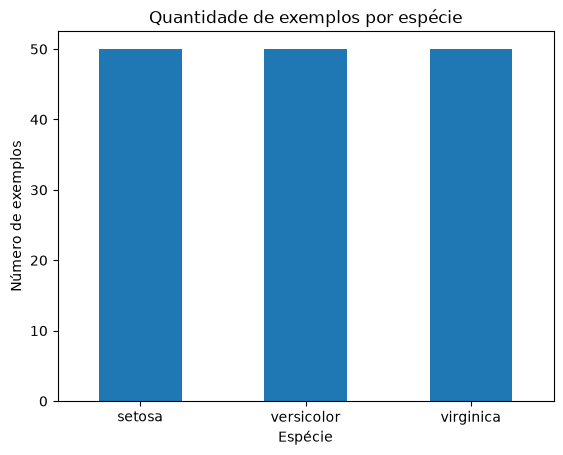

In [18]:

class_counts = df["species"].value_counts().reindex(iris.target_names)

print(class_counts)

ax = class_counts.plot(kind="bar")
ax.set_title("Quantidade de exemplos por espécie")
ax.set_xlabel("Espécie")
ax.set_ylabel("Número de exemplos")
plt.xticks(rotation=0)
plt.show()



### INTERPRETE

1. As classes estão balanceadas?
2. Acurácia parece uma métrica razoável para este problema?
3. Por que uma acurácia de 95% poderia ser enganosa em um dataset com 95% de uma única classe?

**Respostas:**

1. Sim: são 50 exemplos de cada espécie.
2. Sim, como primeira avaliação, pois as classes estão balanceadas. A matriz de confusão e as métricas por classe complementam a análise.
3. Um modelo que sempre previsse a classe majoritária já teria 95% de acurácia, mesmo sem reconhecer nenhum exemplo das outras classes.


### 3.4 Distribuição das features

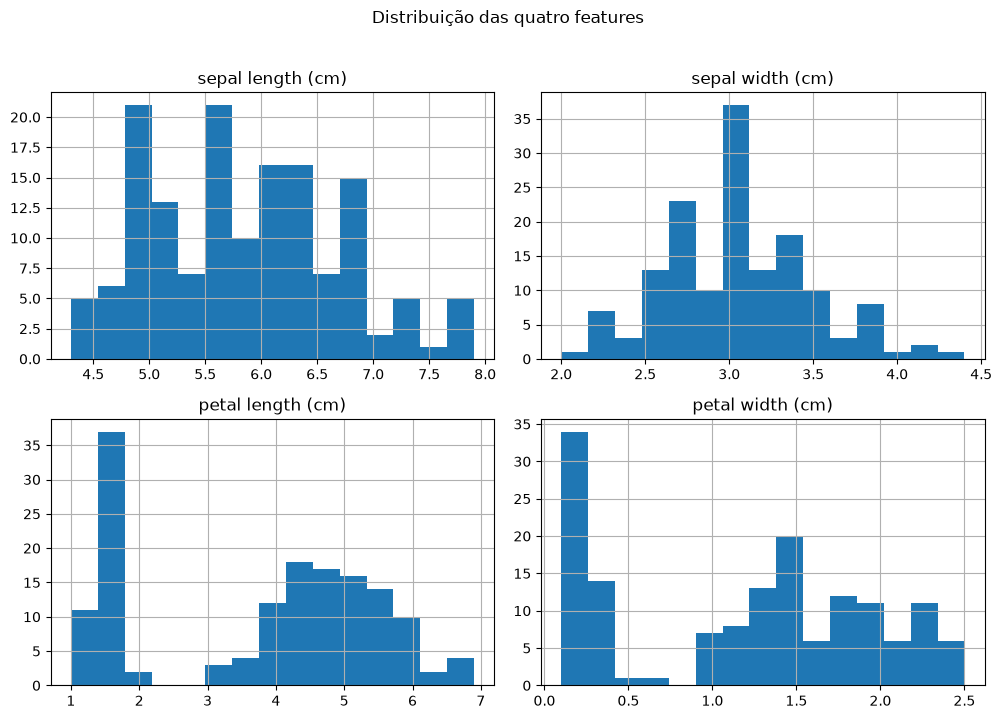

In [19]:

X.hist(figsize=(10, 7), bins=15)
plt.suptitle("Distribuição das quatro features", y=1.02)
plt.tight_layout()
plt.show()



### 3.5 Relação entre duas features

Vamos observar comprimento e largura da pétala.

Complete o código para desenhar as três espécies com marcadores diferentes por cor automática do Matplotlib.


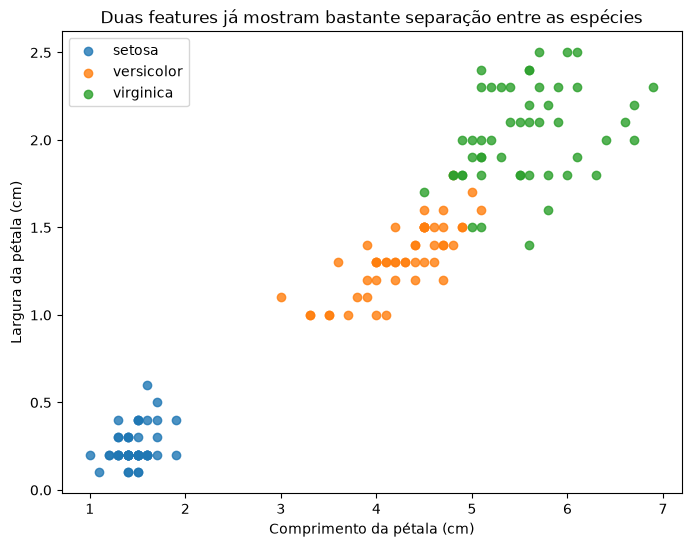

In [20]:

fig, ax = plt.subplots(figsize=(8, 6))

for class_id, class_name in enumerate(iris.target_names):
    mask = y == class_id
    ax.scatter(
        X.loc[mask, "petal length (cm)"],
        X.loc[mask, "petal width (cm)"],
        label=class_name,
        alpha=0.8
    )

ax.set_xlabel("Comprimento da pétala (cm)")
ax.set_ylabel("Largura da pétala (cm)")
ax.set_title("Duas features já mostram bastante separação entre as espécies")
ax.legend()
plt.show()



### INTERPRETE

1. Alguma espécie parece mais fácil de separar visualmente?
2. `versicolor` e `virginica` parecem mais próximas entre si?
3. Isso significa que uma rede neural é obrigatória para resolver o Iris? Explique.

**Respostas sobre os dados:**

1. A espécie `setosa` apresenta uma separação visual mais clara.
2. Sim, `versicolor` e `virginica` estão mais próximas e apresentam sobreposição.

**Resposta 3:** ____________________



# 4. Treino, validação e teste

Vamos trabalhar com três conjuntos:

- **treino**: ajusta os pesos;
- **validação**: acompanha o desenvolvimento;
- **teste**: avaliação final.

## PENSE

Por que não devemos ficar olhando o resultado do teste e mudando a rede até ele melhorar?

Escreva sua resposta antes de continuar.

**Resposta:** Usar repetidamente o teste para escolher alterações faz com que essas decisões se adaptem ao próprio teste. Isso produz uma avaliação otimista e compromete sua função de estimar o desempenho em dados novos. As escolhas devem usar a validação; o teste fica reservado para a avaliação final.



## 4.1 TODO — faça a divisão

Queremos aproximadamente:

- 60% treino;
- 20% validação;
- 20% teste.

Use `random_state=SEED` e preserve a proporção das classes com `stratify`.


In [21]:

# Primeiro: 80% para treino+validação, 20% para teste.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Depois: separamos treino e validação dentro dos 80%.
# 0.25 de 80% = 20% do dataset total.
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.25,
    random_state=SEED,
    stratify=y_trainval
)

print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test.shape, y_test.shape)


Treino: (90, 4) (90,)
Validação: (30, 4) (30,)
Teste: (30, 4) (30,)



### INTERPRETE

1. Quantas flores ficaram em treino?
2. Quantas em validação?
3. Quantas em teste?
4. Por que usamos `stratify`?

**Respostas:**

1. Treino: 90 flores.
2. Validação: 30 flores.
3. Teste: 30 flores.
4. `stratify` preserva a proporção das classes: neste caso, 30 exemplos de cada espécie no treino e 10 de cada espécie em cada um dos outros conjuntos.



# 5. Normalização e vazamento de informação

Usaremos `StandardScaler`.

A transformação é:

\[
x' = \frac{x - \mu}{\sigma}
\]

## PENSE

Qual opção é correta?

**A)** calcular média e desvio usando todos os dados antes do split.  
**B)** calcular média e desvio apenas com o treino e reaplicar a transformação.

Explique por quê.

**Resposta:** A opção B é correta. Média e desvio devem ser calculados somente no treino. Usar todos os dados permitiria que informações da validação e do teste influenciassem a preparação do modelo, causando vazamento de informação.


In [22]:

scaler = StandardScaler()

# Aprende média e desvio SOMENTE do treino.
X_train_scaled = scaler.fit_transform(X_train)

# Apenas aplica a mesma transformação aos outros conjuntos.
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Média aproximada do treino normalizado:")
print(X_train_scaled.mean(axis=0))

print("\nDesvio-padrão aproximado do treino normalizado:")
print(X_train_scaled.std(axis=0))


Média aproximada do treino normalizado:
[ 7.52484494e-16 -7.66670678e-16 -1.11947488e-16 -1.15648232e-16]

Desvio-padrão aproximado do treino normalizado:
[1. 1. 1. 1.]



### INTERPRETE

Por que usamos:

```python
fit_transform(X_train)
```

no treino, mas apenas:

```python
transform(X_val)
transform(X_test)
```

nos outros conjuntos?

**Resposta:** `fit_transform(X_train)` aprende a média e o desvio do treino e aplica a transformação. `transform` reutiliza esses mesmos valores na validação e no teste, sem recalculá-los. Assim, todos os conjuntos usam a mesma transformação, sem vazamento de informação.



# 6. Arquitetura da rede

Vamos construir uma rede simples:

```text
Entrada → Dense(8) → Saída
```

## PENSE ANTES DE CODIFICAR

Responda:

1. Quantos valores entram para cada flor?
2. Quantos neurônios deve ter a saída?
3. Por que?
4. Qual ativação faz sentido na camada oculta?
5. Qual ativação faz sentido na saída?
6. Este problema pede sigmoide ou softmax?


In [23]:

# TODO:
# complete a arquitetura

model = keras.Sequential([
    keras.Input(shape=(X.shape[1],)),
    layers.Dense(8, activation="relu"),
    layers.Dense(len(iris.target_names), activation="softmax")
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)


## 6.1 Quantos parâmetros existem?

Antes de olhar o `model.summary()`, calcule manualmente.

### Primeira Dense

- entradas:
- neurônios:
- pesos:
- biases:
- total:

### Saída

- entradas:
- neurônios:
- pesos:
- biases:
- total:

### Total da rede

Escreva sua conta:

\[
\text{Total} = \_\_\_\_
\]

Depois compare com o `model.summary()`.



### Pergunta conceitual

A ReLU e a softmax adicionam parâmetros treináveis?

Explique.



# 7. `compile()`

A arquitetura já existe. Agora precisamos definir **como ela será treinada**.

Vamos escolher:

- otimizador;
- função de perda;
- métrica.

## PENSE

Nossos rótulos são:

```text
0 = setosa
1 = versicolor
2 = virginica
```

Qual loss faz mais sentido?

- `mse`
- `binary_crossentropy`
- `categorical_crossentropy`
- `sparse_categorical_crossentropy`

Explique sua escolha.


In [24]:

# Veja como os rótulos estão representados:
print(y_train.head(10).to_list())


[2, 0, 1, 0, 2, 2, 2, 1, 0, 1]



### Dica conceitual

- `categorical_crossentropy` costuma ser usada quando o alvo está em one-hot:
  - `[1, 0, 0]`
  - `[0, 1, 0]`
  - `[0, 0, 1]`

- `sparse_categorical_crossentropy` permite usar diretamente:
  - `0`
  - `1`
  - `2`

Agora complete o `compile()`.


In [ ]:

# TODO:

model.compile(
        optimizer="adam", 
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )



### INTERPRETE

Explique em uma frase cada item:

- **optimizer**:
- **loss**:
- **metrics**:



# 8. Treinamento

Durante o treinamento, simplificando:

```text
entrada
  ↓
previsão
  ↓
loss
  ↓
gradientes
  ↓
atualização dos pesos
```

## PENSE

1. O que é uma época?
2. Treinar por mais épocas sempre melhora o modelo em dados novos?
3. O que pode acontecer se a rede continuar aprendendo detalhes específicos demais do treino?


In [33]:

# TODO:
# treine por 100 épocas
# use batch_size=16
# use X_val_scaled e y_val como validation_data
# use verbose=0

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    verbose=0
)

print("Treinamento concluído.")


Treinamento concluído.


## 8.1 Curvas de aprendizado

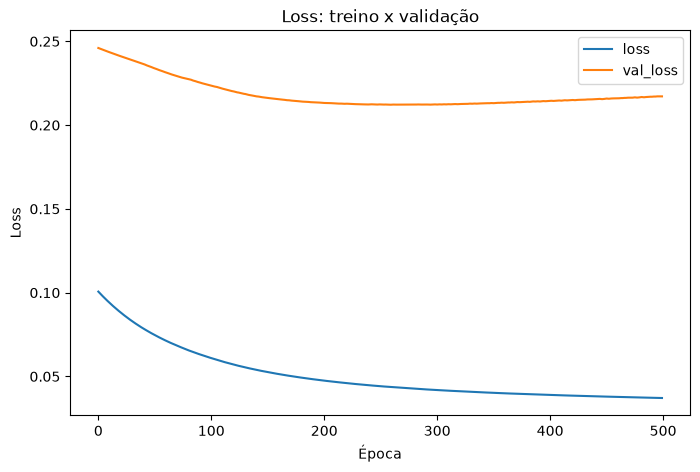

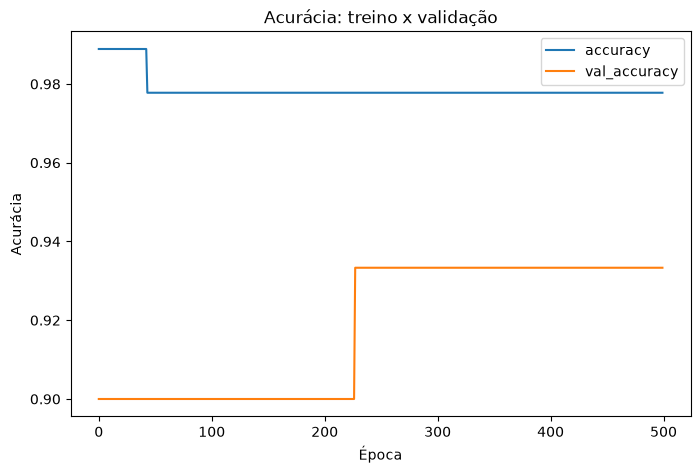

In [32]:

history_df = pd.DataFrame(history.history)

# Loss
ax = history_df[["loss", "val_loss"]].plot(figsize=(8, 5))
ax.set_title("Loss: treino x validação")
ax.set_xlabel("Época")
ax.set_ylabel("Loss")
plt.show()

# Accuracy
ax = history_df[["accuracy", "val_accuracy"]].plot(figsize=(8, 5))
ax.set_title("Acurácia: treino x validação")
ax.set_xlabel("Época")
ax.set_ylabel("Acurácia")
plt.show()



### INTERPRETE AS CURVAS

Responda com base no seu resultado:

1. A loss de treino caiu?
2. A loss de validação caiu?
3. Acurácia de treino e validação ficaram próximas?
4. Há algum sinal de overfitting?
5. Se a loss de treino continuar caindo, isso garante que a rede está melhorando?



# 9. Avaliação final no teste

Agora, e somente agora, vamos medir o desempenho no conjunto de teste.


In [ ]:

# TODO:
# use model.evaluate(...) em X_test_scaled e y_test

test_loss, test_accuracy = ...

print(f"Loss de teste: {test_loss:.4f}")
print(f"Acurácia de teste: {test_accuracy:.4f}")



### INTERPRETE

A acurácia de teste ficou próxima da validação?

Se sim, o que isso sugere?

Se não, que hipóteses poderiam explicar a diferença?



# 10. Entendendo a saída da softmax

Use `model.predict()`.

Lembre-se: há 3 classes, então cada flor deve produzir **3 valores**.


In [ ]:

# TODO:
# obtenha as probabilidades para X_test_scaled

proba = ...

print("Shape:", proba.shape)
print(np.round(proba[:5], 3))



### PENSE

Se o primeiro exemplo produzir:

```text
[0.02, 0.11, 0.87]
```

1. Qual classe seria prevista?
2. As três probabilidades devem somar quanto?
3. Por que usamos softmax neste problema?


In [ ]:

y_pred = np.argmax(proba, axis=1)

comparison = pd.DataFrame({
    "real": [iris.target_names[i] for i in y_test.to_numpy()],
    "previsto": [iris.target_names[i] for i in y_pred],
    "probabilidade_max": proba.max(axis=1)
})

comparison.head(10)


# 11. Matriz de confusão

In [ ]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Matriz de confusão - conjunto de teste")
plt.show()



### INTERPRETE

1. Qual classe foi mais fácil de classificar?
2. Quais classes foram mais confundidas entre si?
3. A matriz de confusão mostra algo que a acurácia sozinha não mostra?

**Orientação para as respostas 1 e 2:** Dependem das previsões obtidas após completar e executar o treinamento. Compare os acertos na diagonal e os erros fora dela.

**Resposta 3:** Sim. A matriz mostra os acertos e as confusões para cada classe, indicando quais espécies o modelo troca entre si; a acurácia apresenta apenas a proporção total de acertos.


## 11.1 Relatório por classe

In [ ]:

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)



### INTERPRETE

Sem decorar as definições formais, observe:

- alguma classe tem `recall` pior?
- alguma classe tem `precision` pior?
- isso é coerente com a matriz de confusão?

**Orientação:** As respostas dependem do relatório gerado após o treinamento. Menor `recall` indica que uma proporção maior dos exemplos reais da classe não foi reconhecida; menor `precision` indica mais erros entre as previsões daquela classe. Esses valores devem ser coerentes com os erros mostrados na matriz de confusão.



# 12. Desafio de debugging — encontre os erros

Considere o código abaixo:

```python
X_scaled = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2
)

model = keras.Sequential([
    keras.Input(shape=(4,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
```

## Tarefa

Encontre **pelo menos 4 problemas ou decisões inadequadas**.

Para cada uma:

1. diga o que está errado;
2. explique por que;
3. diga como corrigir.

### Sua resposta

**Erro 1:** O scaler usa todos os dados antes da divisão, causando vazamento de informação.

**Correção:** Dividir primeiro e ajustar o scaler somente no treino.

**Erro 2:** Faltam estratificação, semente fixa e um conjunto de validação para orientar as escolhas do modelo.

**Correção:** Separar treino, validação e teste com `stratify` e `random_state=SEED`.

**Erro 3:**

**Correção:**

**Erro 4:**

**Correção:**



# 13. Mini-experimento

Escolha **uma única alteração**:

- trocar `Dense(8)` por `Dense(2)`;
- trocar por `Dense(16)`;
- trocar por `Dense(32)`;
- adicionar uma segunda camada oculta;
- remover a normalização;
- aumentar bastante o número de épocas.

## Antes de executar

Preencha:

- Alteração escolhida:
- Número de parâmetros antes:
- Número de parâmetros depois:
- O que você espera que aconteça com o treino?
- O que você espera que aconteça com a validação/teste?


In [ ]:

# TODO:
# construa e treine sua versão modificada aqui.
# Mude APENAS uma coisa em relação ao modelo original.

# Seu código abaixo:



## Resultado do experimento

Preencha:

- Acurácia de treino:
- Acurácia de validação:
- Acurácia de teste:
- Número de parâmetros:
- O resultado foi melhor, pior ou semelhante?
- Sua previsão inicial estava correta?
- O que esse experimento mostra sobre "rede maior = rede melhor"?



# 14. Questões finais

Responda sem executar código novo.

1. Por que a entrada da rede possui 4 valores?
2. Por que a saída possui 3 neurônios?
3. Por que usamos `softmax`?
4. Qual a diferença entre `softmax` e `sigmoid` neste contexto?
5. Por que usamos `sparse_categorical_crossentropy`?
6. Qual a diferença entre `compile()` e `fit()`?
7. O que são os parâmetros treináveis?
8. Por que a ReLU não aumenta o número de parâmetros?
9. Por que o scaler deve ser ajustado apenas no treino?
10. Por que alta acurácia de treino não garante boa generalização?
11. Qual é a função do conjunto de validação?
12. Qual é a função do conjunto de teste?

### Respostas — preparação dos dados e avaliação

9. Para evitar que informações da validação e do teste influenciem a preparação do modelo. Os demais conjuntos usam a transformação aprendida no treino.
10. O modelo pode se ajustar a detalhes específicos do treino e não generalizar para novos exemplos (overfitting).
11. A validação permite acompanhar o desempenho e orientar escolhas de hiperparâmetros durante o desenvolvimento.
12. O teste fornece a avaliação final em dados reservados, sem ser usado para escolher ou ajustar o modelo.

As questões 1 a 8 permanecem para completar.



# 15. Entrega

Antes de enviar:

- [ ] Executei todas as células.
- [ ] Completei todos os `TODO`.
- [ ] Respondi todas as seções `PENSE` e `INTERPRETE`.
- [ ] Fiz o desafio de debugging.
- [ ] Fiz um mini-experimento.
- [ ] Não usei o conjunto de teste para ajustar manualmente a arquitetura.
- [ ] Consigo explicar por que a saída usa `softmax`.
- [ ] Consigo calcular os parâmetros das camadas `Dense`.
